In [1]:
import numpy as np

import yaml
import torch
import h5py 
import pandas as pd
from pathlib import Path

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import sys 
sys.path.append('../')

import src.audio_transforms as at


### Need to make pytorch functions for cue & target level matching in mixutre

* Mix target and distractor 
* scale cue to match target level in mixture 

To do this, we need the following:
* scale factor applied to mixture in rms normalization 

### Note:
The level of the cue matches the level of the target before mixing. When mixing, we scale the distractor's level to achieve a given SNR.  We then normalize the mixture to a given RMS amplitude. The total change in target level is just the scaling applied to reach the RMS value. This means we can just apply that scaling amount to our cue to match its level to the new target level.

In [3]:
h5_path = '/om2/user/msaddler/projects/ibmHearingAid/assets/data/datasets/JSIN_v3.00/nStim_20000/2000ms/rms_0.1/noiseSNR_-10_10/stimSR_20000/reverb_none/noise_all/JSIN_all_v3/subsets/'

file = next(Path(h5_path, 'train_DZKGBOFKNVV2SVR5ZNV7KC5TRMD6P5ZJ').glob('*.h5')).as_posix()

sr = 20_000

In [4]:
file

'/om2/user/msaddler/projects/ibmHearingAid/assets/data/datasets/JSIN_v3.00/nStim_20000/2000ms/rms_0.1/noiseSNR_-10_10/stimSR_20000/reverb_none/noise_all/JSIN_all_v3/subsets/train_DZKGBOFKNVV2SVR5ZNV7KC5TRMD6P5ZJ/JSIN_all__run_000_DZKGBOFKNVV2SVR5ZNV7KC5TRMD6P5ZJ.h5'

In [5]:
sounds = h5py.File(file, 'r')

In [6]:
# audio_transforms = at.AudioCompose([
#             at.AudioToTensor(),
#             at.CombineWithRandomDBSNR(low_snr=0, high_snr=0), # set to 0 so foreground/background at same level 
#             at.RMSNormalizeForegroundAndBackground(rms_level=0.1)
# ])

In [7]:
rms_ratio = np.power(10.0, 10 / 20.0)
scale_factor = .1 / (.1 * rms_ratio)
scale_factor, rms_ratio

(0.3162277660168379, 3.1622776601683795)

In [8]:

next_pow_2 = lambda x: int(pow(2, np.ceil(np.log2(x))))
rms = lambda x: np.sqrt(np.mean(np.power(x,2)))

def combine_with_noise(clean, noise, snr):
    # get ratio in rms 
    rms_ratio = np.power(10.0, snr / 20.0)
    
    # remove DC of each signal
    clean = clean - clean.mean()
    noise = noise - noise.mean()
    # get rms of each signal
    clean_rms = rms(clean)
    noise_rms = rms(noise)
    # scale factor for setting noise to desired SNR 
    scale_factor = clean_rms / (noise_rms * rms_ratio)
    # Blend signals 
    noise = noise * scale_factor
    mixture = clean + noise[:len(clean)]
    return mixture, scale_factor

def rms_normalize(wav, new_rms=0.02, axis=0): 
    wav = wav - wav.mean(axis=axis)
    rms_wav = np.sqrt(np.mean(np.power(wav, 2), axis=axis))
    scale_factor = new_rms / rms_wav
    wav = wav * scale_factor
    return wav, scale_factor
    

In [9]:
# demo mix 
speakers = sounds['sources']['signal']['speaker_int']
signals = sounds['sources']['signal']['signal'] 


In [10]:
index = 0
eg_talker = speakers[index]
eg_target = signals[index]

In [11]:
cue_ixs = np.where(speakers[:] == eg_talker)[0]
all_ixs = np.arange(len(signals))
bg_ixs = np.setdiff1d(all_ixs, cue_ixs)

cue_ixs = cue_ixs[cue_ixs != index]
cue_ix = np.random.choice(cue_ixs)
bg_ix = np.random.choice(bg_ixs)


In [12]:
cue = signals[cue_ix]

In [13]:

bg_talker = speakers[bg_ix]
bg_target = signals[bg_ix]

In [15]:

snr=-10

# target, _ = rms_normalize(eg_target)
# distractor, _  = rms_normalize(bg_target)

mixture, _ = combine_with_noise(eg_target, bg_target, snr)
mixture, mix_scale = rms_normalize(mixture)

# cue, _  = rms_normalize(cue)
# cue_signal = eg_target * first_scale_factor
print(rms(eg_target))
print(rms(mix_scale))

# Eg on what to do if the levels are not normal: put mix scale in units of target 
# cue,_ = rms_normalize(eg_target, 0.1)
cue_signal = cue * rms(eg_target) / rms(cue) * mix_scale
print(rms(cue_signal))

# cue_snr, cue_signal = rove_cue(eg_target,
#                                snr,
#                                mix_scale)
# cue_snr



1.0
0.005999188723601335
0.005999189


In [16]:
mix_scale

0.005999188723601335

In [17]:
cue_signal

array([-0.00444582,  0.00674167,  0.01640063, ...,  0.0098995 ,
        0.00776482, -0.00320683], dtype=float32)

In [18]:
first_scale_factor

NameError: name 'first_scale_factor' is not defined

In [21]:
from IPython.display import Audio

In [22]:
# Audio(cue, rate=sr, normalize=False)

In [23]:
Audio(cue_signal, rate=sr, normalize=False)

In [24]:
Audio(mixture, rate=sr, normalize=False)

In [25]:
rms(cue_signal)

0.005999189

In [26]:
rms(mixture)

0.02

In [32]:
%matplotlib inline 
import matplotlib.pyplot as plt
from scipy import signal



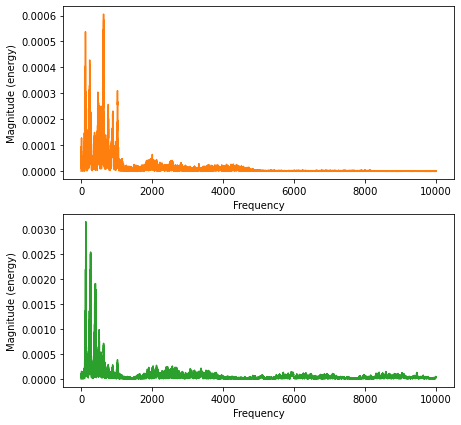

In [33]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(7, 7))
axs[0].magnitude_spectrum(cue_signal, Fs=sr, color='C1');
axs[1].magnitude_spectrum(mixture, Fs=sr,  color='C2');

In [48]:
### Test batch processing of distractors if setting all at same level


In [49]:
distractors = signals[0:5]

In [50]:
distractors.shape

(5, 40000)

In [51]:
audio_transforms = at.AudioCompose([
                at.AudioToTensor(),
                at.RMSNormalizeForegroundAndBackground(rms_level=0.1)
])

In [53]:
audio_transforms(distractors, None)

RuntimeError: Boolean value of Tensor with more than one value is ambiguous

In [60]:
g = lambda x: None



None
